This notebook demonstrates typical plate calibration workflows. 

Calibration establishes transformations between raw RFU values and positions along an assumed reaction coordinate from one system state (i.e. concentration profile) to another.

Typically, a plate contains control samples which track the fluorescence of known, time-invariant concenration profiles over time. To perform a calibration, the user provides negative and positive control samples together their concentration profiles. The result of the calibration are two functions: one mapping from RFU values to concentrations, the other mapping from concentrations to RFU values. Both transformations are linear. I.e., a fluorescence 80% between the negative and the positive control will be mapped onto 80% of the positive plus 20% of the negative concentration profile. For the inverse transformation from concentrations to fluorescence, the average of all concentration change percentages is mapped onto RFU values.

In [1]:
# setup
%matplotlib widget
import xarray as xr
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import nanosuite as ns

# Assay setup

In [2]:
# Where to find the assay (if a relative path is given, its root is jupyter root).
assay_path = "./edc_RFU.xlsx"

# Describe how the samples are grouped into categories
sample_groups = {
    "Calibration": slice("Sample X13", "Sample X16"),
    "Negative": ["Sample X11", "Sample X12"],
    "Positive": ["Sample X17", "Sample X18"],
}

# Describe which of these groups are controls
controls = ['Negative', 'Positive']

In [3]:
# Plate content

# Describe the contentrations of species for each sample in the format below
# Note that we multiply all concentrations by 1e-9 to express nanomol/liter.
content = 1.9*xr.DataArray([
        [0,     10,  0, 0],  # Sample X11
        [0,     10,  0, 0],  # Sample X12
        [0,      8,  1, 2],  # Sample X13
        [0,      6,  2, 4],  # Sample X14
        [0,      4,  3, 6],  # Sample X15
        [0,      2,  4, 8],  # Sample X16
        [0,      0,  5, 10], # Sample X17
        [0,      0,  5, 10], # Sample X18
    ], {
        'sample': [f"Sample X{n}" for n in range(11, 19)],
        'species': ['Input', 'Probe', 'Fuel', 'Signal']
    }
)

In [4]:
assay = ns.Assay(assay_path, sample_groups)

# Plot Methods

In [5]:
# Some methods used for the plots below

def well_color(this, cm = plt.cm.turbo) :
    """Turn well relative index into colourmap entry"""
    f = list(assay.full_plate.well.data).index(this.well.data) / assay.plate.shape[0]
    return cm(f)

def sample_color(sample, cm=plt.cm.turbo):
    return well_color(sample[0], cm=cm)

def plot_raw_rfu(selection, ax, **kwds):
    ax.set_xlabel("time [min]")
    ax.set_ylabel("RFU")
    for sample in pd.Series(selection.sample).unique():
        for content in selection.sel(sample=sample):
            col = well_color(content.well)
            ax.plot(selection.time, content,
                    color=col, label=content.well.data, **kwds)

def plot_raw_rfu_sample_stats(selection, ax, **kwds):
    ax.set_xlabel("time [min]")
    ax.set_ylabel("RFU")
    for sample in pd.Series(selection.sample).unique():
        contents = selection.sel(sample=sample)
        mean = contents.mean(axis=0)
        std = contents.std(axis=0)
        col = sample_color(contents.well)
        plt.fill_between(selection.time, mean-std, mean+std, color=col, alpha=.2)
        plt.plot(selection.time, mean, label=sample, color=col, **kwds)

def plot_mean_and_errors(selection, means, errors, ax, color=None, **kwds):
    for well, smoothed, noise in zip(selection, means, errors):
        col = color or well_color(well)
        ax.plot(smoothed.time, smoothed, '-', color=col)
        ax.plot(smoothed.time, smoothed-noise, '--', color=col)
        ax.plot(smoothed.time, smoothed+noise, '--', color=col)

# Conversion Methods

**Direct conversion** takes the average fluorescence of all wells of the negative (positive) control *at each point in time* and sets it equivalent to the negative (positive) concentration profile.

In [6]:
# Compute direct calibration transforms
from_rfu, to_rfu = assay.convert(
    assay.plate.sel(group='Positive'),
    assay.plate.sel(group='Negative'),
    content.sel(sample='Sample X17'),
    content.sel(sample='Sample X11'),
    method='direct'
)

The following plots show the individual sample wells and averages for the positive and negative control.

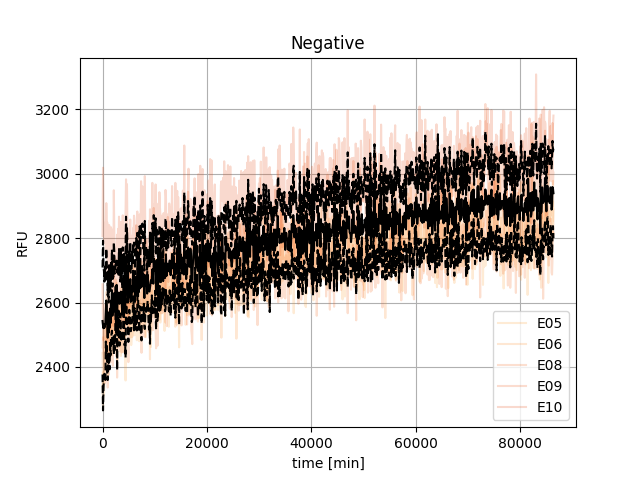

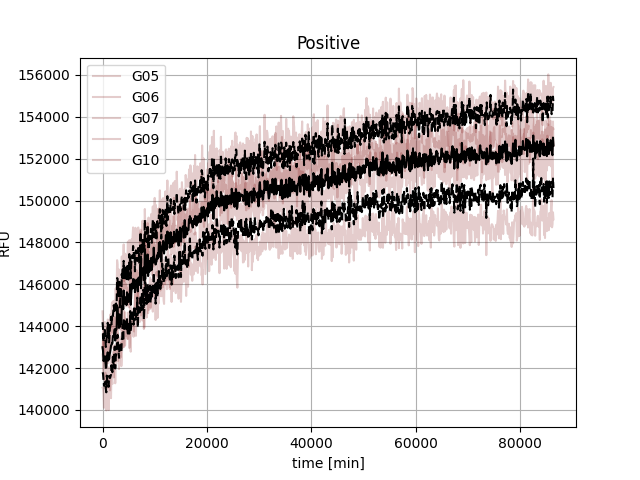

In [9]:
for control in controls:
    selection = assay.plate.sel(group=control)

    calibration = to_rfu(content.sel(sample=selection.sample)[0])
    std = (selection-calibration).std(axis=0)

    fig, ax = plt.subplots()
    plt.title(selection.group.data)
    plot_raw_rfu(selection, ax, alpha=.2)
    #plot_raw_rfu_sample_stats(selection, ax)
    plot_mean_and_errors(selection, [calibration], [std], ax, color="black")
    ax.legend()
    ax.grid()
    plt.show()

Alternatively, we can calibrate to a **relaxation model**. This assumes that the time evolution of the control fluorescence can be well described by a double relaxation process: the fluorescence quickly relaxes tword an equilibrium value, which itself slowly relaxes toward another equilibrium.

In [10]:
# Compute direct calibration transforms
from_rfu, to_rfu = assay.convert(
    assay.plate.sel(group='Positive'),
    assay.plate.sel(group='Negative'),
    content.sel(sample='Sample X17'),
    content.sel(sample='Sample X11'),
    method='relaxation'
)

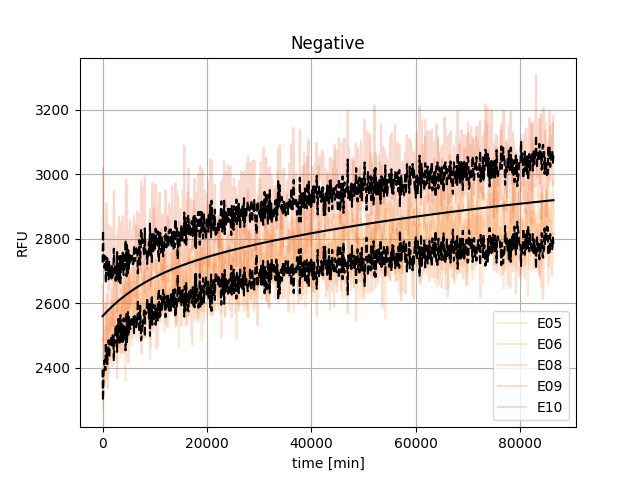

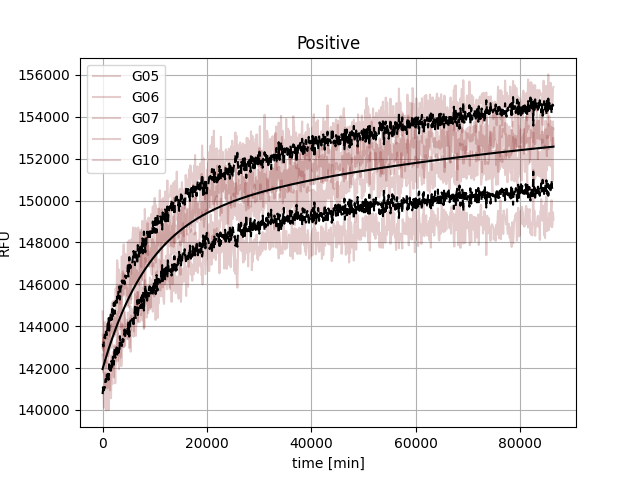

In [11]:
for control in controls:
    selection = assay.plate.sel(group=control)

    calibration = to_rfu(content.sel(sample=selection.sample)[0])
    std = (selection-calibration).std(axis=0)
    
    fig, ax = plt.subplots()
    plt.title(selection.group.data)
    plot_raw_rfu(selection, ax, alpha=.2)
    #plot_raw_rfu_sample_stats(selection, ax, alpha=.2)
    plot_mean_and_errors(selection, [calibration], [std], ax, color="black")
    ax.legend()
    ax.grid()
    plt.show()

# Using the transformations

The returned functions can be used to map between RFU and concentrations.

The assay used here contains a group of samples -- titled *"Calibration"* -- which are set up to track the example reaction at 20%, 40%, 60% and 80% completion. We will use these samples to analyze how well the result of the calibration procedure matches these known concentration profiles.

In [12]:
# From concentrations to RFU
calibrated = to_rfu(content)

In [13]:
selection = assay.plate[assay.plate.group.isin(["Calibration"]+controls)]

In [14]:
calibrated.dims

('sample', 'time')

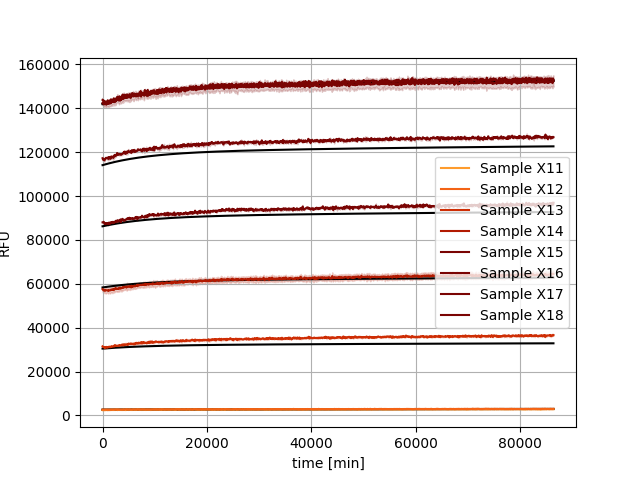

In [15]:
fig, ax = plt.subplots()
for sample in calibrated:
    ax.plot(sample.time, sample, color="black")
plot_raw_rfu_sample_stats(selection, ax)
ax.legend()

ax.grid()

In [16]:
# From RFU to concentrations
inverse = from_rfu(assay.plate).sel(species="Signal")

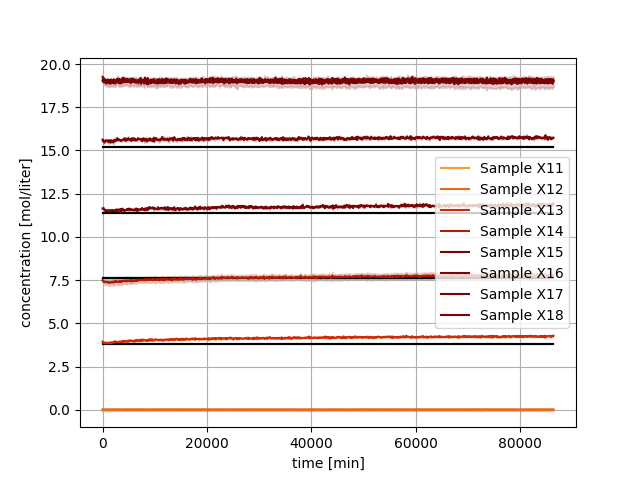

In [17]:
selection = inverse[inverse.group.isin(["Calibration"]+controls)]

fig, ax = plt.subplots()
for sample in selection.sample:
    reference = content.sel(sample=sample, species='Signal').data
    ax.plot(selection.time, reference*np.ones_like(selection.time), color="black")
plot_raw_rfu_sample_stats(selection, ax)
ax.legend()
ax.set_ylabel("concentration [mol/liter]")
ax.grid()